# Lab4 Henrik

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, roc_curve

In [40]:
url = 'data/Titanic_Cleaned.csv'

In [41]:
df = pd.read_csv(url, sep=',')
df.head()

,PassengerId,Survived,Pclass,SibSp,Parch,HasCabin,CatAge,CatFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Unique
0,1,0.0,3,1,0,False,0,0,True,False,True,False,True,False,False
1,2,1.0,1,1,0,True,3,3,False,False,False,False,False,True,False
2,3,1.0,3,0,0,False,1,1,False,False,True,True,False,False,False
3,4,1.0,1,1,0,True,2,3,False,False,True,False,False,True,False
4,5,0.0,3,0,0,False,2,1,True,False,True,False,True,False,False


In [42]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   1309 non-null   int64  
 1   Survived      891 non-null    float64
 2   Pclass        1309 non-null   int64  
 3   SibSp         1309 non-null   int64  
 4   Parch         1309 non-null   int64  
 5   HasCabin      1309 non-null   bool   
 6   CatAge        1309 non-null   int64  
 7   CatFare       1309 non-null   int64  
 8   Sex_male      1309 non-null   bool   
 9   Embarked_Q    1309 non-null   bool   
 10  Embarked_S    1309 non-null   bool   
 11  Title_Miss    1309 non-null   bool   
 12  Title_Mr      1309 non-null   bool   
 13  Title_Mrs     1309 non-null   bool   
 14  Title_Unique  1309 non-null   bool   
dtypes: bool(8), float64(1), int64(6)
memory usage: 81.9 KB


,PassengerId,Survived,Pclass,SibSp,Parch,CatAge,CatFare
count,1309.000000,891.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,655.000000,0.383838,2.294882,0.498854,0.385027,1.381207,1.486631
std,378.020061,0.486592,0.837836,1.041658,0.865560,1.112474,1.122135
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,655.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000
75%,982.000000,1.000000,3.000000,1.000000,0.000000,2.000000,2.000000
max,1309.000000,1.000000,3.000000,8.000000,9.000000,3.000000,3.000000


In [43]:
df_train = df[df['Survived'].notnull()]
df_test = df[df['Survived'].isnull()]

df_train.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

print("Training set shape:", df_train.shape)
print("Test set shape:", df_test.shape)

Training set shape: (891, 15)
Test set shape: (418, 15)


In [44]:
df_train.to_csv('data/train.csv', index=False)
df_test.to_csv('data/test.csv', index=False)

In [45]:
url_train = 'data/train.csv'
url_test = 'data/test.csv'

In [46]:
df_train = pd.read_csv(url_train)
df_test = pd.read_csv(url_test)

In [47]:
df_train.head()

,PassengerId,Survived,Pclass,SibSp,Parch,HasCabin,CatAge,CatFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Unique
0,1,0.0,3,1,0,False,0,0,True,False,True,False,True,False,False
1,2,1.0,1,1,0,True,3,3,False,False,False,False,False,True,False
2,3,1.0,3,0,0,False,1,1,False,False,True,True,False,False,False
3,4,1.0,1,1,0,True,2,3,False,False,True,False,False,True,False
4,5,0.0,3,0,0,False,2,1,True,False,True,False,True,False,False


In [48]:
df_test.head()

,PassengerId,Survived,Pclass,SibSp,Parch,HasCabin,CatAge,CatFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Unique
0,892,NaN,3,0,0,False,2,0,True,True,False,False,True,False,False
1,893,NaN,3,1,0,False,3,0,False,False,True,False,False,True,False
2,894,NaN,2,0,0,False,3,1,True,True,False,False,True,False,False
3,895,NaN,3,0,0,False,1,1,True,False,True,False,True,False,False
4,896,NaN,3,1,1,False,0,1,False,False,True,False,False,True,False


In [49]:
df_train['TravelAlone'] = (df_train['SibSp']+df_train['Parch'] == 0).astype(int)

In [50]:
df_train.head()

,PassengerId,Survived,Pclass,SibSp,Parch,HasCabin,CatAge,CatFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Unique,TravelAlone
0,1,0.0,3,1,0,False,0,0,True,False,True,False,True,False,False,0
1,2,1.0,1,1,0,True,3,3,False,False,False,False,False,True,False,0
2,3,1.0,3,0,0,False,1,1,False,False,True,True,False,False,False,1
3,4,1.0,1,1,0,True,2,3,False,False,True,False,False,True,False,0
4,5,0.0,3,0,0,False,2,1,True,False,True,False,True,False,False,1


In [51]:
df_train.drop('SibSp', axis=1, inplace=True)
df_train.drop('Parch', axis=1, inplace=True)

In [52]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'HasCabin', 'CatAge', 'CatFare',
       'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Unique', 'TravelAlone'],
      dtype='object')

(-1.0, 4.0)

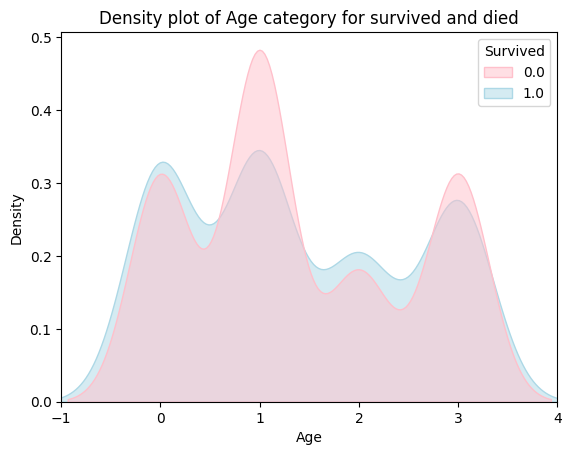

In [53]:
sns.kdeplot(data=df_train, x='CatAge', hue='Survived', fill=True, palette={1:'lightblue', 0: 'pink'}, common_norm=False, alpha=0.5)
plt.title('Density plot of Age category for survived and died')
plt.xlabel('Age')
plt.xlim(-1, 4)

(-1.0, 4.0)

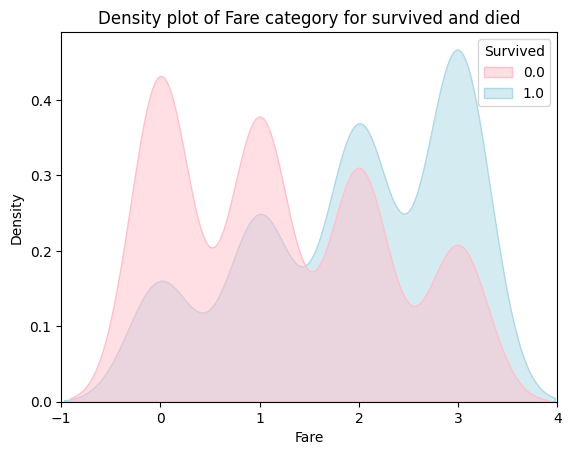

In [54]:
sns.kdeplot(data=df_train, x='CatFare', hue='Survived', fill=True, palette={1:'lightblue', 0: 'pink'}, common_norm=False, alpha=0.5)
plt.title('Density plot of Fare category for survived and died')
plt.xlabel('Fare')
plt.xlim(-1, 4)

(-1.0, 4.0)

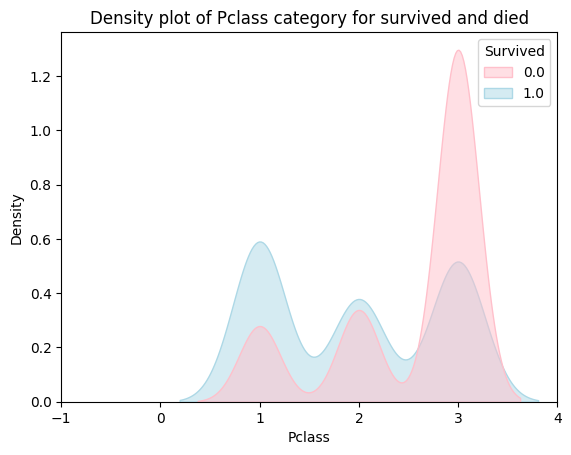

In [55]:
sns.kdeplot(data=df_train, x='Pclass', hue='Survived', fill=True, palette={1:'lightblue', 0: 'pink'}, common_norm=False, alpha=0.5)
plt.title('Density plot of Pclass category for survived and died')
plt.xlabel('Pclass')
plt.xlim(-1, 4)

(-1.0, 2.0)

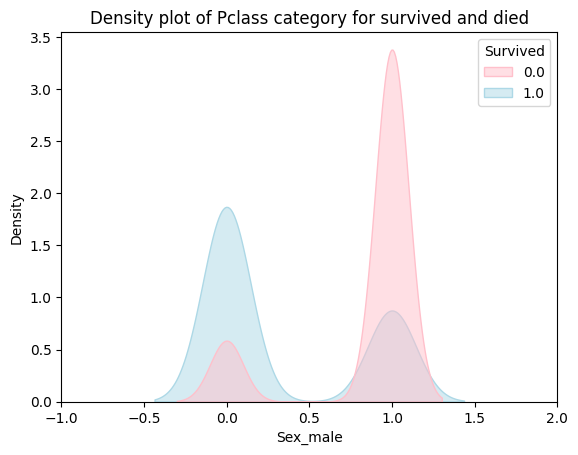

In [56]:
sns.kdeplot(data=df_train, x='Sex_male', hue='Survived', fill=True, palette={1:'lightblue', 0: 'pink'}, common_norm=False, alpha=0.5)
plt.title('Density plot of Pclass category for survived and died')
plt.xlabel('Sex_male')
plt.xlim(-1, 2)

(-1.0, 2.0)

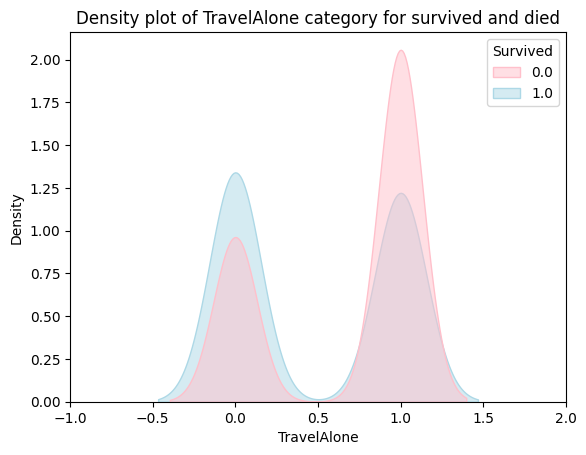

In [57]:
sns.kdeplot(data=df_train, x='TravelAlone', hue='Survived', fill=True, palette={1:'lightblue', 0: 'pink'}, common_norm=False, alpha=0.5)
plt.title('Density plot of TravelAlone category for survived and died')
plt.xlabel('TravelAlone')
plt.xlim(-1, 2)

Text(0.5, 1.0, 'Correlation Matrix of df_train features')

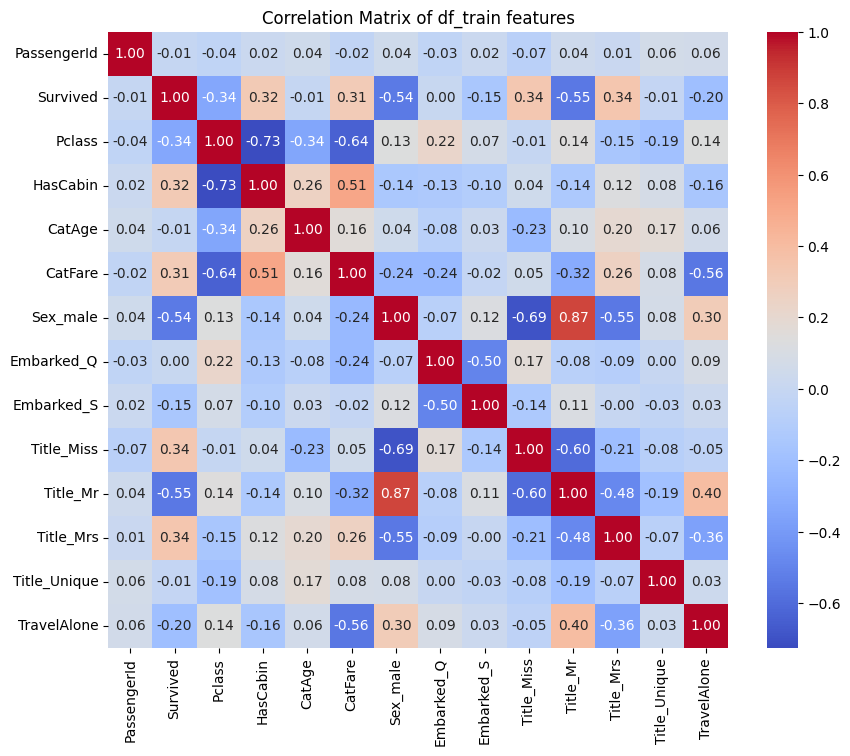

In [58]:
correlation_matrix = df_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of df_train features')

In [59]:
X = df_train.drop(['PassengerId', 'Survived'], axis=1)
y = df_train['Survived']

In [60]:
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=8)
rfe.fit(X, y)
selected_features = X.columns[rfe.support_]
print('Selected features:', selected_features)

Selected features: Index(['Pclass', 'HasCabin', 'Sex_male', 'Embarked_S', 'Title_Miss',
       'Title_Mr', 'Title_Unique', 'TravelAlone'],
      dtype='object')


In [61]:
X = df_train[selected_features]
y = df_train['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

              precision    recall  f1-score   support

         0.0       0.83      0.82      0.82       105
         1.0       0.75      0.76      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



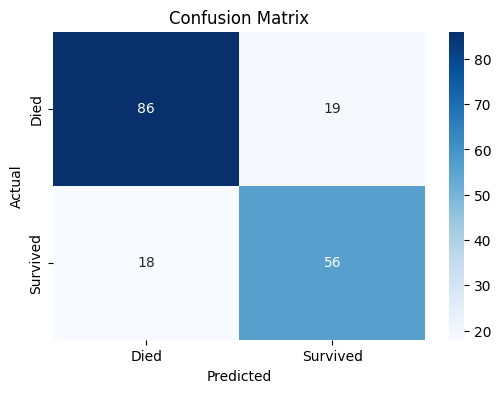

In [65]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

print(classification_report(y_test, y_pred))

Accuracy: 0.79
Log loss: 0.43
AUC: 0.87


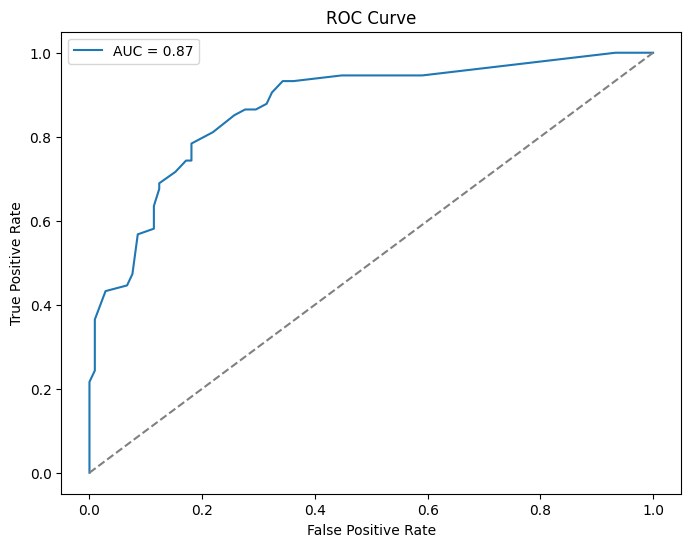

In [76]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 2))

y_pred_proba = model.predict_proba(X_test)[:,1]
logloss = log_loss(y_test, y_pred_proba)
print("Log loss:", round(logloss, 2))

auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", round(auc, 2))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

In [82]:
model = LogisticRegression(max_iter=1000)
scores_accuracy = cross_val_score(model, X, y, cv=10, scoring='accuracy')
print("Average accuracy:", round(scores_accuracy.mean(), 2))

scores_log_loss = cross_val_score(model, X, y, cv=10, scoring='neg_log_loss')
print("Average Log loss:", round(-scores_log_loss.mean(), 2))

scores_auc = cross_val_score(model, X, y, cv=10, scoring='roc_auc')
print("Average AUC", round(scores_auc.mean(), 2))

Average accuracy: 0.81
Average Log loss: 0.44
Average AUC 0.86
